In [12]:
import requests

import folium
from folium.plugins import HeatMap
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Explainer Notebook - Final Project
02806 Social Data Analysis and Visualization - Spring 2026 - Group 42 

## Motivation
<!-- What is your dataset? -->
<!-- Why did you choose this/these particular dataset(s)? -->
<!-- What was your goal for the end user's experience? -->

### The data sets
The aim of this analysis is to showcase if socioeconomic hardship is correlated to a rise in criminal activity. The hypothesis is, that areas with a higher hardship will have a tendency to a higher crime rate, specifically in the sector of "blue-collar" crime (aka street crime). To make that analysis we will be zooming in on the city of Chicago, US, as an example. We are employing two data sets from, both collected by the city itself, to explore the possible connection between crime and socioeconomic status. 

### Why this data?
The first data set, referred to as the "socioeconomic" data set was chosen for the clear distinction of various social factors in different parts of Chicago. This data set will allow us to analyze the needed factors and compare them to a geolocation.

The other data set, referred to as the "crime" data set was chosen to showcase the crime landscape in Chicago. This data set also has access to geolocation data, which is based on the same locational categories as the ones seen in the socioeconomic data set. Since both data sets are collected by the authorities, they fit nicely together (in terms of format), and have a high level of credibility.

One caveat about the data is, that the socioeconomic data was last collected in the time period of 2008-2012 making it rather old. This analysis is therefore limited to that era.

### Main goal of analysis
We are hoping that the collected visualizations of these data sets will create an immersive journey for the reader in which they will be intrigued, not only by the correlations between hardship and crime, but by the world of visual data.

## Basic Stats
<!-- Basic stats. Let's understand the dataset better -->
<!-- Write about your choices in data cleaning and preprocessing -->
<!-- Write a short section that discusses the dataset stats, containing key points/plots from your exploratory data analysis. -->

<!-- Basic stats. Let's understand the dataset better -->

### Socioeconomic data
Find the data set at [City of Chicago - social](https://data.cityofchicago.org/Health-Human-Services/Census-Data-Selected-socioeconomic-indicators-in-C/kn9c-c2s2/about_data).

The first data set for this project is the Census data set collected by the city of Chicago. The aim of this data set is to document and explore the tendencies of poverty, employment, age, and education in the different communities of Chicago. In the data set we also see a custom "Hardship" score, which is an aggregation of the other parameters normalized by the area of the community.

Now, let's have a look at a sample of the data

In [13]:
sd = pd.read_csv('./data/sociodata.csv')
print(f"{len(sd)} rows, {len(sd.columns)} columns")
# sd.describe()
sd.sample(frac=1).reset_index(drop=True).head(5)

78 rows, 9 columns


,Community Area Number,COMMUNITY AREA NAME,PERCENT OF HOUSING CROWDED,PERCENT HOUSEHOLDS BELOW POVERTY,PERCENT AGED 16+ UNEMPLOYED,PERCENT AGED 25+ WITHOUT HIGH SCHOOL DIPLOMA,PERCENT AGED UNDER 18 OR OVER 64,PER CAPITA INCOME,HARDSHIP INDEX
0,50.0,Pullman,1.5,21.6,22.8,13.1,38.6,20588,51.0
1,43.0,South Shore,2.8,31.1,20.0,14.0,35.7,19398,55.0
2,5.0,North Center,0.3,7.5,5.2,4.5,26.2,57123,6.0
3,22.0,Logan Square,3.2,16.8,8.2,14.8,26.2,31908,23.0
4,46.0,South Chicago,4.7,29.8,19.7,26.6,41.1,16579,75.0


The data sample allows us to have an early, rough, look at the data. We can see that, except for the location, all data is in a numeric format. Most columns are presented as percentage, and thus in the range of 0 - 100. The income column is a bit different using an integer-based value and a much different range. There are 78 rows, one for each community area (and a "total" column).

#### Preprocessing
<!-- Write about your choices in data cleaning and preprocessing -->
Running through the data set there are a few things that spring to mind in terms of preprocessing. Firstly, there seem to be some spelling errors in the names of the names of the community areas, e.g. "Montclare" has been named "Montclaire" by accident. Additionally, and this is perhaps the most dangerous; the column for "PER CAPITA INCOME " has a trailing space, which can complicate some debugging down the line. Apart from that there are no errors or inconsistencies in the data. No missing values either.

#### Data set discussion
<!-- Write a short section that discusses the dataset stats, containing key points/plots from your exploratory data analysis. -->
As seen in the example we have data about the various socioeconomic factors explained previously, as well as the geographic community area. This gives an obvious opportunity to visualize the data as a choropleth plot. This visualization will allow us to analyze where, in geographical terms, there is high "hardship" in the city, as well as easily look at correlations between the different factors. This helps answer the "Where is the hardship in Chicago" part of the question we are ultimately asking.

#### What have we learned from the data?
<!-- Describe your data analysis and explain what you've learned about the dataset.Describe your data analysis and explain what you've learned about the dataset. -->
The plots helps us learn that the hardship is mostly centered in the south-western regions of the city. The coastline, especially the northern part, seems to be where the money is at (literally). The rough outline is that the more rural areas of the city are riddled with high poverty rate, low employment, and low income, while the downtown areas have a much lower hardship. Another clear fact springing to mind is just how high the poverty is, with areas reaching a per-household poverty of 56%.

### Crime data

Find this data set at [City of Chicago - crime](https://data.cityofchicago.org/Public-Safety/Crimes-2001-to-Present/ijzp-q8t2/about_data).

The second data set is the crime data, which conveniently is also collected by the city of Chicago. The aim of this data set is to explore the landscape of crime in the city, much like we have been doing throughout this course with the city of San Francisco. In difference to the socioeconomic data set, this set is quite a bit larger and features a few more columns of useful values. Not only do we get detailed infomation on the type of crime, but precise geolocation, community areas, timestamp, etc.

Let's draw a sample here as well:

In [14]:
cd = pd.read_csv('./data/crimedata.csv')
print(f"{len(cd)} rows, {len(cd.columns)} columns")
cd_copy = cd.copy()
# cd.describe()
cd.sample(frac=1).reset_index(drop=True).head(5)

1878569 rows, 22 columns


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,6958359,HR363860,06/02/2009 10:00:00 AM,041XX W 26TH ST,1310,CRIMINAL DAMAGE,TO PROPERTY,COMMERCIAL / BUSINESS OFFICE,False,False,...,22.0,30.0,14,1149399.0,1886406.0,2009,02/28/2018 03:56:25 PM,41.844218,-87.727227,"(41.844218175, -87.727226939)"
1,7140676,HR550031,09/22/2009 10:50:00 AM,053XX W FULLERTON AVE,0560,ASSAULT,SIMPLE,PARKING LOT/GARAGE(NON.RESID.),False,False,...,37.0,19.0,08A,1140166.0,1915435.0,2009,02/28/2018 03:56:25 PM,41.924051,-87.760400,"(41.924051234, -87.760399665)"
2,8949177,HV621369,12/29/2012 10:48:00 PM,060XX W SHERWIN AVE,0560,ASSAULT,SIMPLE,STREET,False,False,...,41.0,12.0,08A,1135118.0,1948562.0,2012,02/10/2018 03:50:01 PM,42.015046,-87.778160,"(42.015045891, -87.778159575)"
3,8689797,HV363890,07/02/2012 04:48:00 PM,088XX S BURLEY AVE,2820,OTHER OFFENSE,TELEPHONE THREAT,RESIDENCE,False,False,...,7.0,46.0,08A,1199205.0,1846967.0,2012,09/23/2025 03:41:47 PM,41.734886,-87.545777,"(41.734885649, -87.545776576)"
4,6284474,HP372007,06/02/2008 11:45:00 PM,004XX E 61ST ST,2027,NARCOTICS,POSS: CRACK,SIDEWALK,True,False,...,20.0,42.0,18,1180450.0,1864671.0,2008,02/28/2018 03:56:25 PM,41.783918,-87.613944,"(41.783917722, -87.613943689)"


In this view we see the juice of the crime data; coordinates, precise timestamps, crime descriptions, community areas (the same as in the socioeconomic data set). We also see that there is a whooping 1,878,569 rows and 22 columns. 
print(f"{len(cd)} rows, {len(cd.columns)} columns")

#### Preprocessing
<!-- Write about your choices in data cleaning and preprocessing -->
The crimes data set is made rather professionally, and we wont need a lot of preprocessing. However, we chose to omit crimes, in which the location is unknown (NaN value), as most crime data is visualized through geographical plots.
Additionally, we have chosen to base most visualizations on a subset of only 1000 rows of data, as showing the full 1.8 million crimes often resulted in a significant lag on the webpage, but supported our conclusions equally well.

#### Data set discussion
<!-- Write a short section that discusses the dataset stats, containing key points/plots from your exploratory data analysis. -->
Analyzing the crime data we can learn quite a few things. We mainly use the data to visualize where various types of crime happens in a geographical sense.
In short, this data set allows us to conclude if the locations of crimes are correlated with the locations of most hardship. As simple as that conclusion might seem there is some "triggyness" to it. This mainly stems from the fact that the locations noted in the data is the location of arrest (very sensible), but what we are really after is the residence location of the perpetrator. Had the data been as such, it would have been easier to conclude, not just if the crimes happen in rough areas, but also if the perpetrators are people from rough neighborhoods. This forces us to split the data based on various crimes and draw conclusions from there, rather than look at a collective view.

#### What have we learned from the data?
<!-- Describe your data analysis and explain what you've learned about the dataset.Describe your data analysis and explain what you've learned about the dataset. -->
For certain crimes, e.g. gambling and narcotics, it seems to be the case that crime happens in the rougher areas. But for other types, such as theft and prostitution, this is not necessarily the case. The reason is likely that the those crimes are committed further from home, and rather where there exist appropriate "victims" (if you can call it as such). We learn that there is a big difference in the geographical fingerprint of the different crimes, and it becomes clear that locations of crimes follow specific logical patterns related to the nature of the crime rather than the population of the city.

### Population data
Find this data set at [City of Chicago - population](https://gist.github.com/bread-fixer/758862b6cec426334e2412bda847de28)
The final dataset is a population data set, this dataset is a csv file with ethnicities and population of each community area in Chicago in 2010 and 2020. This dataset was primiarly used for calculating the crime rate per 10k inhabitants, which is a more accurate way of comparing crime across different areas, as it takes into account the population size of each area. An article about the dataset can be found [here](https://breadpricefixer.medium.com/chicago-census-2020-an-extremely-mixed-bag-9b3125d5c70d).

In [15]:
population_data = pd.read_csv('./data/populationdata.csv')
print(f"{len(population_data)} rows, {len(population_data.columns)} columns")
# population_data.describe()
population_data.sample(frac=1).reset_index(drop=True).head(5)

77 rows, 55 columns


,GEOID,GEOG,TOT_POP,POP_HH,POP_GQ,HISP,WHITE,BLACK,ASIAN,OTHER,...,HU_TOT_CHANGE,WHITE_PCT_CHANGE,ASIAN_PCT_CHANGE,HISP_PCT_CHANGE,BLACK_PCT_CHANGE,OTHER_PCT_CHANGE,HH_SIZE_PCT_CHANGE,TOT_HH_PCT_CHANGE,TOT_POP_PCT_CHANGE,HU_TOT_PCT_CHANGE
0,77,Edgewater,56296,53265,3031,8466,30962,6820,7316,2732,...,327,0.3,1.4,-1.5,-2.2,2.0,-3.9,3.2,-0.4,1.0
1,9,Edison Park,11525,11524,1,1239,9538,62,308,378,...,-4,-5.6,0.3,3.0,0.2,2.1,2.7,0.1,3.0,-0.1
2,30,South Lawndale,71399,66262,5137,61970,2328,6246,206,649,...,957,-0.6,0.2,4.2,-4.4,0.5,-12.9,10.7,-9.9,4.5
3,38,Grand Boulevard,24589,24368,221,754,633,22262,85,855,...,617,0.8,0.0,1.3,-3.6,1.5,-1.3,14.1,12.1,5.1
4,39,Kenwood,19116,18954,162,763,3121,12965,1364,903,...,923,-0.2,1.6,1.0,-4.1,1.5,-1.2,10.0,7.1,9.0




#### Preprocessing
<!-- Write about your choices in data cleaning and preprocessing -->
This dataset did not require much preprocessing, as it was already in a clean format. We simply had to pull out the population data for each community area and merge it with the socioeconmic and crime data sets, to be able to calculate the crime rate per 10k inhabitants for each community area.

#### Data set discussion
<!-- Write a short section that discusses the dataset stats, containing key points/plots from your exploratory data analysis. -->
This dataset was crucial for understanding correlations between crime and socioeconomic factors, as it allowed us to calculate the crime rate per 10k inhabitants for each community area. By being able to compare crime rates across different areas, we were able to draw more accurate conclusions about the relationship between crime and socioeconomic.

#### What have we learned from the data?
<!-- Describe your data analysis and explain what you've learned about the dataset.Describe your data analysis and explain what you've learned about the dataset. -->
While the population data itself did not provide any direct insights, it did contain information about ethnicities in each community area, which could be used for further analysis. However, our main focus was on using the population data to calculate crime rates per 10k inhabitants and look at socioecnomic indicators for the crimes.. Unfortunately, our 2 initial datasets only stretched from 2008 to 2012 therefore not allowing us to make use of the full potential of the population data, which also included data from 2020.

## Genre

<!-- Which genre of data story did you use? -->
<!-- Which tools did you use from each of the 3 categories of Visual Narrative (Figure 7 in Segal and Heer). Why? -->
<!-- Which tools did you use from each of the 3 categories of Narrative Structure (Figure 7 in Segal and Heer). Why? -->

#### Genre of the Data Story

Our data story follows a "Slide Show" narrative structure with elements of a "Partitioned Poster" where our narrative is divided into three sequential scenes; Hardship Indicators, Criminal Landscape, and Interpretation. Additionally, we also include a final "Discussion and Conclussion" page.

Each scene contains a title, a short explanatory text, and one or more visualizations. This creates a hybrid genre, that supports both a coherent narrative flow and local user exploration. The "Slide show" aspect provides a clear, author-driven progression. The "Partitioned Poster" aspect allows each section to stand alone as a self-contained block.


#### Visual Tools

##### Visual Structuring
We have chosen the following tools to provide orientation and help the reader understand how each part contributes to the overall argument. 

- Establishing Shot / Overview: The homepage introduces the theme, motivation, and three-step structure.
- Consistent Visual Platform: Each section follows the same pattern: title, short explanation, visualization.
- Checklist-like Structure: The numbered sections act as a roadmap for the narrative.


##### Highlighting
Highlighting ensures that important geographic patterns are immediately visible and that the viewer notices the intended relationships before interacting with the visualization.

- Feature Distinction: Different crime types and socioeconomic variables are visually separated.
- Captions and Explanatory Text: Each visualization is accompanied by short text guiding the viewer’s attention.


##### Transition Guidance
The following tools makes the story more clear and helps the reader understand how each step builds toward the final interpretation.

- Clear Section Boundaries: Each step is seperated by different pages, making transitions explicit.
- Introductory Text: Each section begins with a short explanation preparing the reader for the upcoming visualization.



#### Narrative Tools

#### Ordering

We have chosen the following tools because the linear structure ensures that the viewer follows the intended logic, while local exploration increases engagement.

- Linear Ordering: The narrative follows a fixed sequence: Hardship -> Crime -> Interpretation -> Discussion.
- Local Exploration: Users can explore maps and indicators within each section, but the overall order remains author-driven.


##### Interactivity

The following tools ensure that interactivity enhances the user experience without disrupting the intended narrative flow.

- Hover / Details-on-Demand: Users can inspect specific neighborhoods or crime types.
- Filtering or Selection: Users can toggle variables or crime categories (depending on implementation).
- Constrained Interactivity: Interaction is allowed within scenes but not across the narrative structure.


##### Messaging

These tools ensure that the viewer understands the argument, not just the visuals. They frame the data, provide context, and guide the interpretation of the data.

- Headlines and Section Titles: Each section clearly states its theme.
- Introductory Text: The homepage explains the purpose and limitations of the data.
- Short Explanatory Descriptions: Each visualization includes a concise explanation of what the user should learn.


## Visualizations and Data analysis
<!-- Explain the visualizations you've chosen. -->
<!-- Why are they right for the story you want to tell? -->

### Choropleth plots (Socioeconomic data set)

The map-plots were chosen to create a visual connection between the geographical data and the numeric. While possible, simply displaying the socioeconomic factors in a bar chart / histogram would not have given the same immersive effect. This type of plot instead allows the user to get a feel for where the issue exists. What exact citizens suffer under hardship? Additionally, these plots align well the geographic data in the crime data set and it presented a good opportunity for a qualitative assessment of the correlation between the two data sets.

The choropleth maps reveals a socioeconomic divide across Chicago. Community areas on the West and South sides consistently show higher hardship, poverty and unemployment together with a lower per capita income. In contrast the North Side and lakefront neighborhoods have lower hardship scores and substantially higher incomes. This aligns well with the hardship index being constructed from the socioeconomic conditions. The maps overall show how socioeconomics indicators follows very similar geographical patterns. This is done by highlighting the divide between more wealthy and more disadvataged communities. 

In [16]:
def _get_shapes_file() -> dict:
    """Return geojson for chicago community areas"""
    # import shapefile for community areas
    shapefile = requests.get("https://data.cityofchicago.org/resource/igwz-8jzy.json").json()

    # And convert them to proper geojson format
    geojson = {
        "type": "FeatureCollection",
        "features": [
            {
                "type": "Feature",
                "geometry": row["the_geom"],
                "properties": {k: v for k, v in row.items() if k != "the_geom"},
            }
            for row in shapefile
            if row.get("the_geom") and row["the_geom"].get("coordinates")
        ],
    }
    return geojson

def _align_naming_schemes(df: pd.DataFrame) -> pd.DataFrame:
    """Align the naming schemes of the comminity areas (city of chicago misspelled some names in the census data... smh)"""
    df = df.copy()
    # Spell correction
    name_fixes = {
        "MONTCLAIRE": "MONTCLARE",
        "WASHINGTON HEIGHT": "WASHINGTON HEIGHTS",
        "O'HARE": "OHARE",
    }
    df["COMMUNITY AREA NAME"] = df["COMMUNITY AREA NAME"].str.upper().replace(name_fixes)
    # Exclude the "total" row
    df = df[df["COMMUNITY AREA NAME"] != "CHICAGO"]
    return df

def plot_income_choropleth(col: str, filename: str, plot_data: pd.DataFrame, geojson: dict) -> None:
    import plotly.express as px
    import plotly.graph_objects as go

    fig = go.Figure(
        data=px.choropleth_map(
            plot_data,
            geojson=geojson,
            locations="COMMUNITY AREA NAME",
            color=col,
            featureidkey="properties.community",
            color_continuous_scale="Magma",
            map_style="carto-positron",
            zoom=9,
            center={"lat": 41.8781, "lon": -87.6298},
            opacity=0.6,
        )
    )
    fig.update_layout(margin={"r": 0, "t": 0, "l": 0, "b": 0})
    fig.write_html(f"./../docs/figures/{filename}", include_plotlyjs="cdn")

geojson = _get_shapes_file()
plot_data = _align_naming_schemes(sd)

# Generate choropleth plots for the 4 main columns
plot_income_choropleth("HARDSHIP INDEX", "hardship_choropleth.html", plot_data, geojson)
plot_income_choropleth("PER CAPITA INCOME ", "income_choropleth.html", plot_data, geojson) # Yes, trailing space is on purpose... smh
plot_income_choropleth("PERCENT HOUSEHOLDS BELOW POVERTY", "poverty_choropleth.html", plot_data, geojson)
plot_income_choropleth("PERCENT AGED 16+ UNEMPLOYED", "unemployment_choropleth.html", plot_data, geojson)

### Folium maps

The folium map plots showcase the areas in which various types of crime happens. The idea is to show a representative subsample of specific crime categories, in which there is a clear difference in the geographical fingerprint. Showing the data in this type of map-plot allows for that easy qualitative correlation analysis mentioned previously.

The folium heatmaps reveals clear geographic differences between crime types in Chicago. For Gambling and Narcotics heatmaps we can see that the crimes a concentrated primarily on the west and south sides where the hardship score is higher. In contrast, theft is most common downtown and along the north lakefront where the population density and tourism are the highest. The Prostitution heatmap shows a linear pattern along major streets and transportation corridors. These maps demonstrates how different crimes are associated with different neighborhood characteristics and are far from evenly distributed across the city.

In [17]:
def generate_heatmap(df: pd.DataFrame, n_samples: int = 1000, category: str = "All"):
    """Generate folium heatmap from crime data."""
    df = df.copy()

    # Create map
    m = folium.Map(location=[df["Latitude"].mean(), df["Longitude"].mean()], zoom_start=10)
    # Filter cat
    if category.strip().lower() != "all":
        df = df[df['Primary Type'] == category.strip().upper()]
    # Draw random sample for n points
    subset = df.dropna(subset=["Latitude", "Longitude"]).sample(frac=1).reset_index(drop=True).head(n_samples)
    print(f"Generating heatmap for category: {category} with {len(subset)} samples.")
    heat_data = [[row["Latitude"], row["Longitude"]] for index, row in subset.iterrows()]

    # plot data
    HeatMap(heat_data).add_to(m)
    m.save(f"./../docs/figures/crime_map_{category.lower().replace(' ', '_')}.html")

generate_heatmap(cd, n_samples=1000, category="ALL")
generate_heatmap(cd, n_samples=1000, category="THEFT")
generate_heatmap(cd, n_samples=1000, category="NARCOTICS")
generate_heatmap(cd, n_samples=1000, category="ASSAULT")
generate_heatmap(cd, n_samples=1000, category="GAMBLING")
generate_heatmap(cd, n_samples=1000, category="PROSTITUTION")

Generating heatmap for category: ALL with 1000 samples.
Generating heatmap for category: THEFT with 1000 samples.
Generating heatmap for category: NARCOTICS with 1000 samples.
Generating heatmap for category: ASSAULT with 1000 samples.
Generating heatmap for category: GAMBLING with 1000 samples.
Generating heatmap for category: PROSTITUTION with 1000 samples.


### Cluster plots

The cluster plots, made from the crimes data set and seen in the crime page, shows a quantitative view of how we can analyze the geographical data. Using the clusters in this case made it possible to properly document if the hot-spots described from the heatmaps were accurate. It enabled us to draw the conclusion that the theft crimes do not follow the narrative of "more crimes happen in areas with high hardship". 

The cluster plots show how different crime types are concentrated in different parts of Chicago. 
For the Gambling Cluster plot we can sse how two clear clusters on the West and South side which is both areas with high hardship. This indicates that there is a strong link to socioeconomic disadvantages. 
For the Theft Cluster plot we see a very different pattern with several clusters centered around downtown and along the north lakefront where commercial activity and income levels are higher. These two plots shows us how crime is not evenly distributed across the city and that each crime type follows its own geographic pattern which is driven by different underlying factors.

In [18]:
def plot_crime_clusters(cd: pd.DataFrame, crime_type: str, n_clusters: int, output: str):
    tmp = cd[cd['Primary Type'].str.lower() == crime_type.lower().strip()].copy()
    tmp = tmp.dropna(subset=['Latitude', 'Longitude'])
    tmp = tmp.sample(frac=1).reset_index(drop=True).head(1000)

    colors = px.colors.qualitative.Plotly
    fig = go.Figure()

    cluster_data = {}
    kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(tmp[['Latitude', 'Longitude']])
    tmp['cluster'] = kmeans.labels_
    cluster_data = {i: tmp[tmp['cluster'] == i] for i in range(n_clusters)}

    # Add crime points
    for cluster_id in range(n_clusters):
        fig.add_trace(
            go.Scatter(
                x=cluster_data[cluster_id]['Longitude'],
                y=cluster_data[cluster_id]['Latitude'],
                mode='markers',
                name=f'Cluster: {cluster_id}',
                marker=dict(
                    size=6,
                    color=colors[cluster_id % len(colors)],
                    opacity=0.7,
                ),
                text=[f"{crime_type}<br>Cluster: {cluster_id}"] * len(cluster_data[cluster_id]),
                hovertemplate='%{text}<extra></extra>',
                legendgroup=f'{crime_type}_{n_clusters}'
            )
        )

    # Add cluster centers
    for i, center in enumerate(kmeans.cluster_centers_):
        fig.add_trace(
            go.Scatter(
                x=[center[1]],
                y=[center[0]],
                mode='markers',
                name=f'Center {i}',
                marker=dict(
                    size=15,
                    color=colors[i % len(colors)],
                    symbol='star',
                    line=dict(color='black', width=2)
                ),
                text=f'Cluster {i} Center',
                hovertemplate='%{text}<extra></extra>',
                legendgroup=f'{crime_type}_{n_clusters}',
                showlegend=False
            )
        )

    fig.update_layout(
        title=f'Crime Clusters for {crime_type} (K={n_clusters})',
        xaxis_title='Longitude',
        yaxis_title='Latitude',
        legend_title='Clusters',
        hovermode='closest',
        width=1030,
        height=600,
    )

    # Save to HTML for embedding in website
    fig.write_html(output)

plot_crime_clusters(cd, crime_type="GAMBLING", n_clusters=2, output="./../docs/figures/gambling_clusters.html")
plot_crime_clusters(cd, crime_type="THEFT", n_clusters=4, output="./../docs/figures/theft_clusters.html")

### Correlation plot for Hardship and crime types

The correlation plot gives us a quantitative way to compare how different crime types relate to the hardship index across Chicago community areas. Using this we can evaluate whether the patterns observed in the maps are consistent when looking at individual crime categories. The plot are also used to identify differences in how strongly each crime type aligns with socioeconomic conditions.

From the correlation plot we can see that there is a clear pattern where many violent and public-order crimes tend to be more common in higher-hardship neighborhoods, while several property-related or non-violent offenses show weaker or even slightly negative relationships. For the lower hardship areas crimes such as deceptive practices, theft, and some narcotic-related violations are weakly associated with the areas. In contrast, more serious crimes such as homicide, weapons violations, battery, assault, and narcotics-related offenses tend to be more concentrated in areas with higher hardship index values, suggesting a strong geographical overlap between socioeconomic disadvantage and more severe forms of crime.

It is important to note that the plot shows correlation, not causation. The relationships displayed reflect patterns of association across neighborhoods rather than direct cause-and-effect links, and may be influenced by a range of underlying structural and contextual factors.

In [19]:
mapping = {sd['Community Area Number'][i]: sd['COMMUNITY AREA NAME'][i] for i in range(len(sd))}
cd['Community Area'] = cd_copy['Community Area'].map(mapping)

crime_by_type = (
    cd
    .groupby(["Community Area", "Primary Type"])
    .size()
    .reset_index(name="count")
)

crime_pivot = crime_by_type.pivot(
    index="Community Area",
    columns="Primary Type",
    values="count"
).fillna(0)

crime_pivot = crime_pivot.reset_index()

merged_types = sd.merge(
    crime_pivot,
    left_on="COMMUNITY AREA NAME",
    right_on="Community Area",
    how="inner"
)

# 1. Ensure only crime columns are used
crime_columns = crime_pivot.columns.tolist()
crime_columns.remove("Community Area")

# 2. Compute correlation manually (avoids .corr() issues)
corr_with_hardship = merged_types[crime_columns].apply(
    lambda x: x.corr(merged_types["HARDSHIP INDEX"])
)

# 3. Drop any NaNs (some crime types may be constant = no variance)
corr_with_hardship = corr_with_hardship.dropna()

# 4. Convert to clean DataFrame for Plotly
plot_df = corr_with_hardship.sort_values().reset_index()
plot_df.columns = ["Crime Type", "Correlation"]

# 5. Plot (fully aligned)
fig = px.bar(
    plot_df,
    x="Correlation",
    y="Crime Type",
    orientation="h",
    title="Correlation of Crime Types with Hardship Index",
)

fig.update_layout(
    height=800,  # improves readability
    yaxis_title="Crime Type",
    xaxis_title="Correlation"
)

filename = "crime_hardship_correlation.html"

fig.write_html(f"./../docs/figures/{filename}", include_plotlyjs="cdn")

fig.show()

### Correlation for specific crime types and socioeconomic factors

The first plot is an interactive visualization showing the overall crime count per 10,000 inhabitants for each community area relative to various socioeconomic factors. This tool provides a high-level overview of how crime correlates with different social indicators, allowing users to easily switch between variables to identify the strongest relationships. Notably, the percentage of households below the poverty line and the unemployment rate (age 16+) demonstrated the strongest positive correlations with crime. Because poverty and unemployment are also highly correlated with each other, we selected the strongest predictor, this being households below poverty for our final analysis. Additionally, per capita income exhibited a strong negative correlation with crime, prompting further investigation.

The final visualization combines two scatter plots to examine the relationship between narcotics crime (per 10,000 inhabitants) and two key socioeconomic factors: "PERCENT HOUSEHOLDS BELOW POVERTY" and "PER CAPITA INCOME". Trendlines and R² values are included to quantify the strength of these relationships. The results show there is a positive correlation between poverty and narcotics crime, and a notable negative correlation between income and narcotics crime. This suggests that across Chicago communities, higher poverty rates align with more narcotics offenses, whereas higher income levels align with fewer. However, while these socioeconomic factors are strongly associated with crime patterns, correlation does not equal causation, and many other underlying variables are likely at play.

In [20]:
import plotly.graph_objects as go
import os
import numpy as np
from sklearn.linear_model import LinearRegression


mapping = {sd['Community Area Number'][i]: sd['COMMUNITY AREA NAME'][i] for i in range(len(sd))}
cd['Community Area'] = cd_copy['Community Area'].map(mapping)
crime_by_community = cd.groupby('Community Area').size().reset_index(name='Crime Count')
crime_by_community = crime_by_community.sort_values(by='Crime Count', ascending=False)
population_area_and_pop = population_data[['GEOG', 'TOT_POP_2010']]
sociodata_and_population = sd.merge(population_area_and_pop, left_on='COMMUNITY AREA NAME', right_on='GEOG')
sociodata_and_population.drop(columns=['GEOG'], inplace=True)

merged_data = pd.merge(
    crime_by_community,
    sociodata_and_population,
    left_on='Community Area',
    right_on='COMMUNITY AREA NAME',
    how='inner'
)
merged_data['Crime Count Per 10k'] = (merged_data['Crime Count'] / merged_data['TOT_POP_2010']) * 10000

merged_data = merged_data[merged_data['Community Area'] != 'CHICAGO']

feature_cols = [
    col for col in sd.columns
    if col not in ['Community Area Number', 'COMMUNITY AREA NAME']
]

# Ensure HARDSHIP INDEX is the first feature so it shows by default
if 'HARDSHIP INDEX' in feature_cols:
    feature_cols.remove('HARDSHIP INDEX')
    feature_cols.insert(0, 'HARDSHIP INDEX')

# Create output directory if it doesn't exist
os.makedirs('../docs/figures', exist_ok=True)

fig = go.Figure()
buttons = []
initial_title = ""

for i, feature in enumerate(feature_cols):
    # Ensure correct data type
    if merged_data[feature].dtype == 'object':
        merged_data[feature] = merged_data[feature].str.replace(',', '.').astype(float)
        
    x = merged_data[feature].values.reshape(-1, 1)
    y = merged_data['Crime Count Per 10k'].values

    model = LinearRegression().fit(x, y)
    r2 = model.score(x, y)
    r = np.sqrt(max(0, r2)) * (1 if model.coef_[0] >= 0 else -1)

    # Determine visibility (only the first feature is visible by default)
    is_visible = (i == 0)
    title_text = f'Crime Count Per 10k vs {feature}<br>R² = {r2:.3f}'
    if is_visible:
        initial_title = title_text

    # Add scatter trace
    fig.add_trace(go.Scatter(
        x=merged_data[feature], 
        y=y, 
        mode='markers',
        name='Community Areas',
        text=merged_data['Community Area'],
        hovertemplate='<b>%{text}</b><br>' + feature + ': %{x}<br>Crime Count Per 10k: %{y:.2f}<extra></extra>',
        visible=is_visible
    ))
    
    # Add trendline trace
    x_range = np.linspace(merged_data[feature].min(), merged_data[feature].max(), 100).reshape(-1, 1)
    y_range = model.predict(x_range)
    
    fig.add_trace(go.Scatter(
        x=x_range.flatten(), 
        y=y_range, 
        mode='lines', 
        name='Trendline: R = {:.3f}'.format(r), 
        line=dict(color='red'),
        visible=is_visible
    ))

    # Create visibility mask for the dropdown (2 traces per feature)
    visibility = [False] * (len(feature_cols) * 2)
    visibility[i * 2] = True
    visibility[i * 2 + 1] = True

    # Add dropdown button for this feature
    buttons.append(
        dict(
            label=feature,
            method='update',
            args=[
                {'visible': visibility},
                {
                    'title.text': title_text,
                    'xaxis.title.text': feature,
                    'yaxis.title.text': 'Crime Count Per 10k Residents'
                }
            ]
        )
    )

# Add dropdown and set initial layout
fig.update_layout(
    updatemenus=[{
        'active': 0,
        'buttons': buttons,
        'x': 1.0,
        'xanchor': 'left',
        'y': 1.15,
        'yanchor': 'top'
    }],
    title=initial_title,
    xaxis_title=feature_cols[0],
    yaxis_title='Crime Count Per 10k Residents',
    margin=dict(t=100) # Give space for the dropdown and title
)

# Create a combined HTML file
fig.write_html("../docs/figures/crime_vs_sociodata_combined.html")
fig.show()


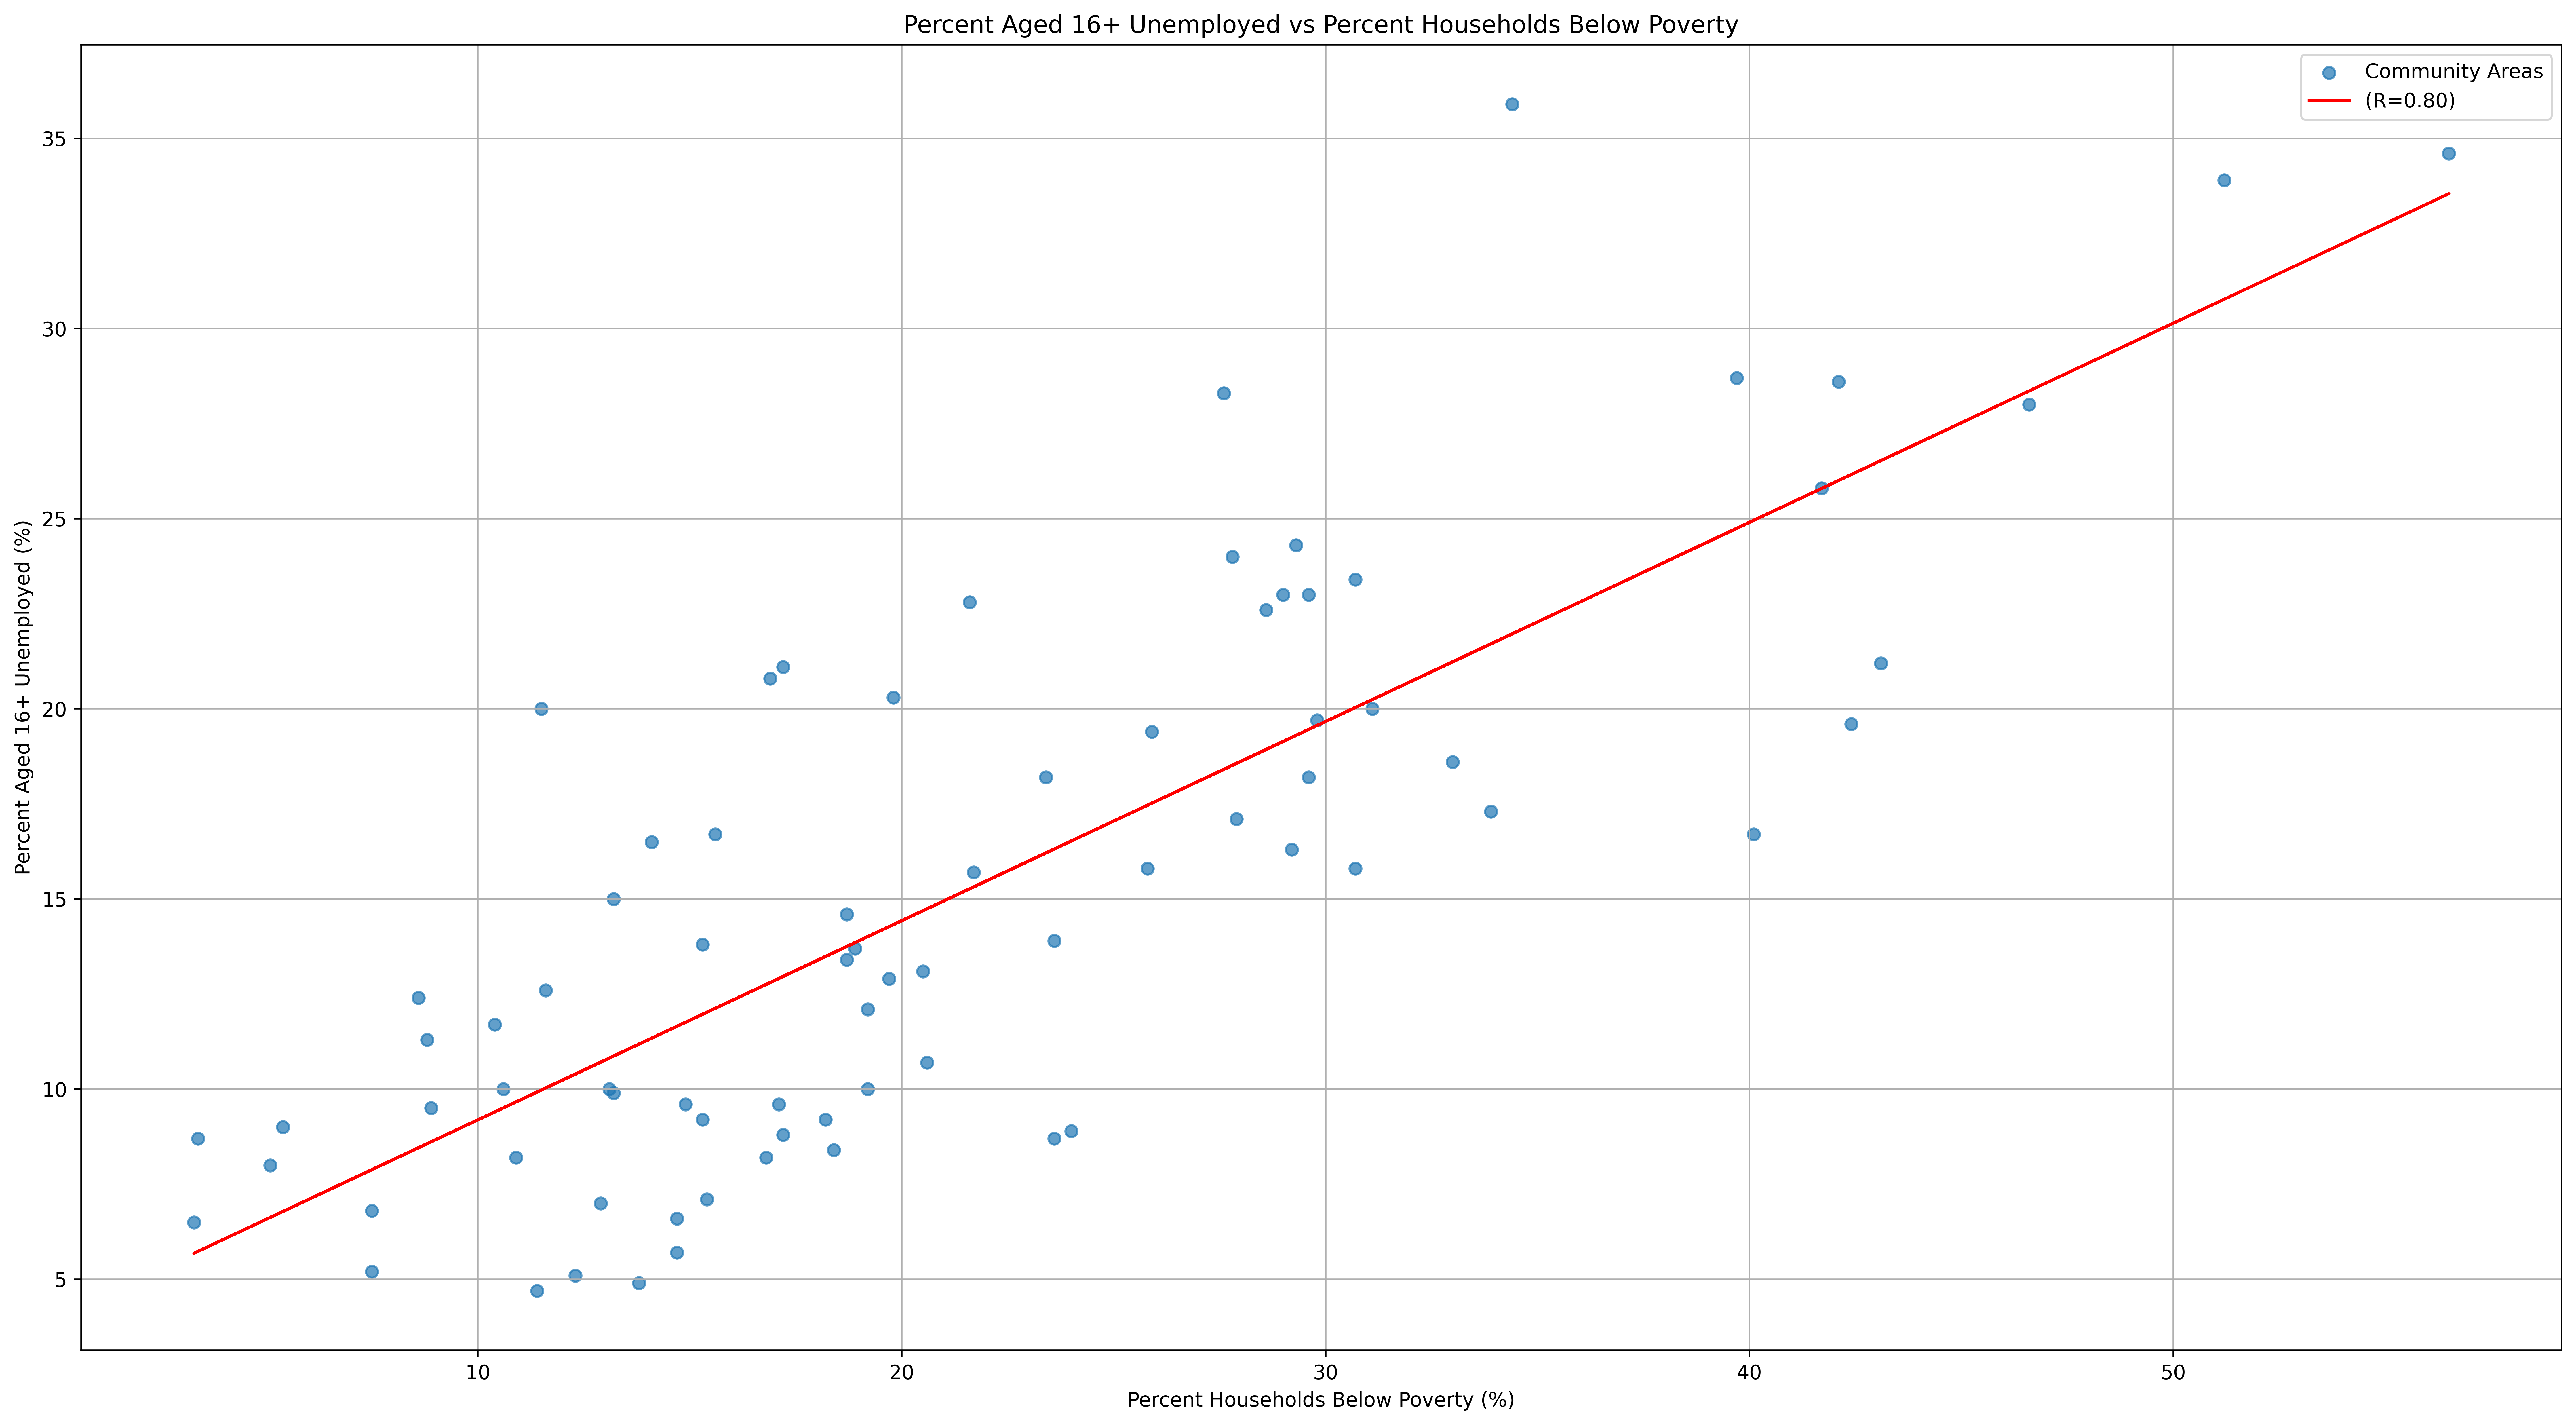

In [21]:
x_data = sd['PERCENT HOUSEHOLDS BELOW POVERTY']
y_data = sd['PERCENT AGED 16+ UNEMPLOYED']

if x_data.dtype == 'object':
    x_data = x_data.str.replace(',', '.').astype(float)
if y_data.dtype == 'object':
    y_data = y_data.str.replace(',', '.').astype(float)

plt.figure(figsize=(18,10), dpi=500)
plt.scatter(x_data, y_data, alpha=0.7, label='Community Areas')
plt.title('Percent Aged 16+ Unemployed vs Percent Households Below Poverty')
correlation = np.corrcoef(x_data, y_data)[0, 1]
line_of_best_fit = np.polyfit(x_data, y_data, 1)
plt.plot(x_data, line_of_best_fit[0] * x_data + line_of_best_fit[1], color='red', label=f'(R={correlation:.2f})')
plt.legend()
plt.xlabel('Percent Households Below Poverty (%)')
plt.ylabel('Percent Aged 16+ Unemployed (%)')
plt.grid(True)
plt.tight_layout()
plt.savefig('../docs/figures/unemployment_vs_poverty.png')
plt.show()

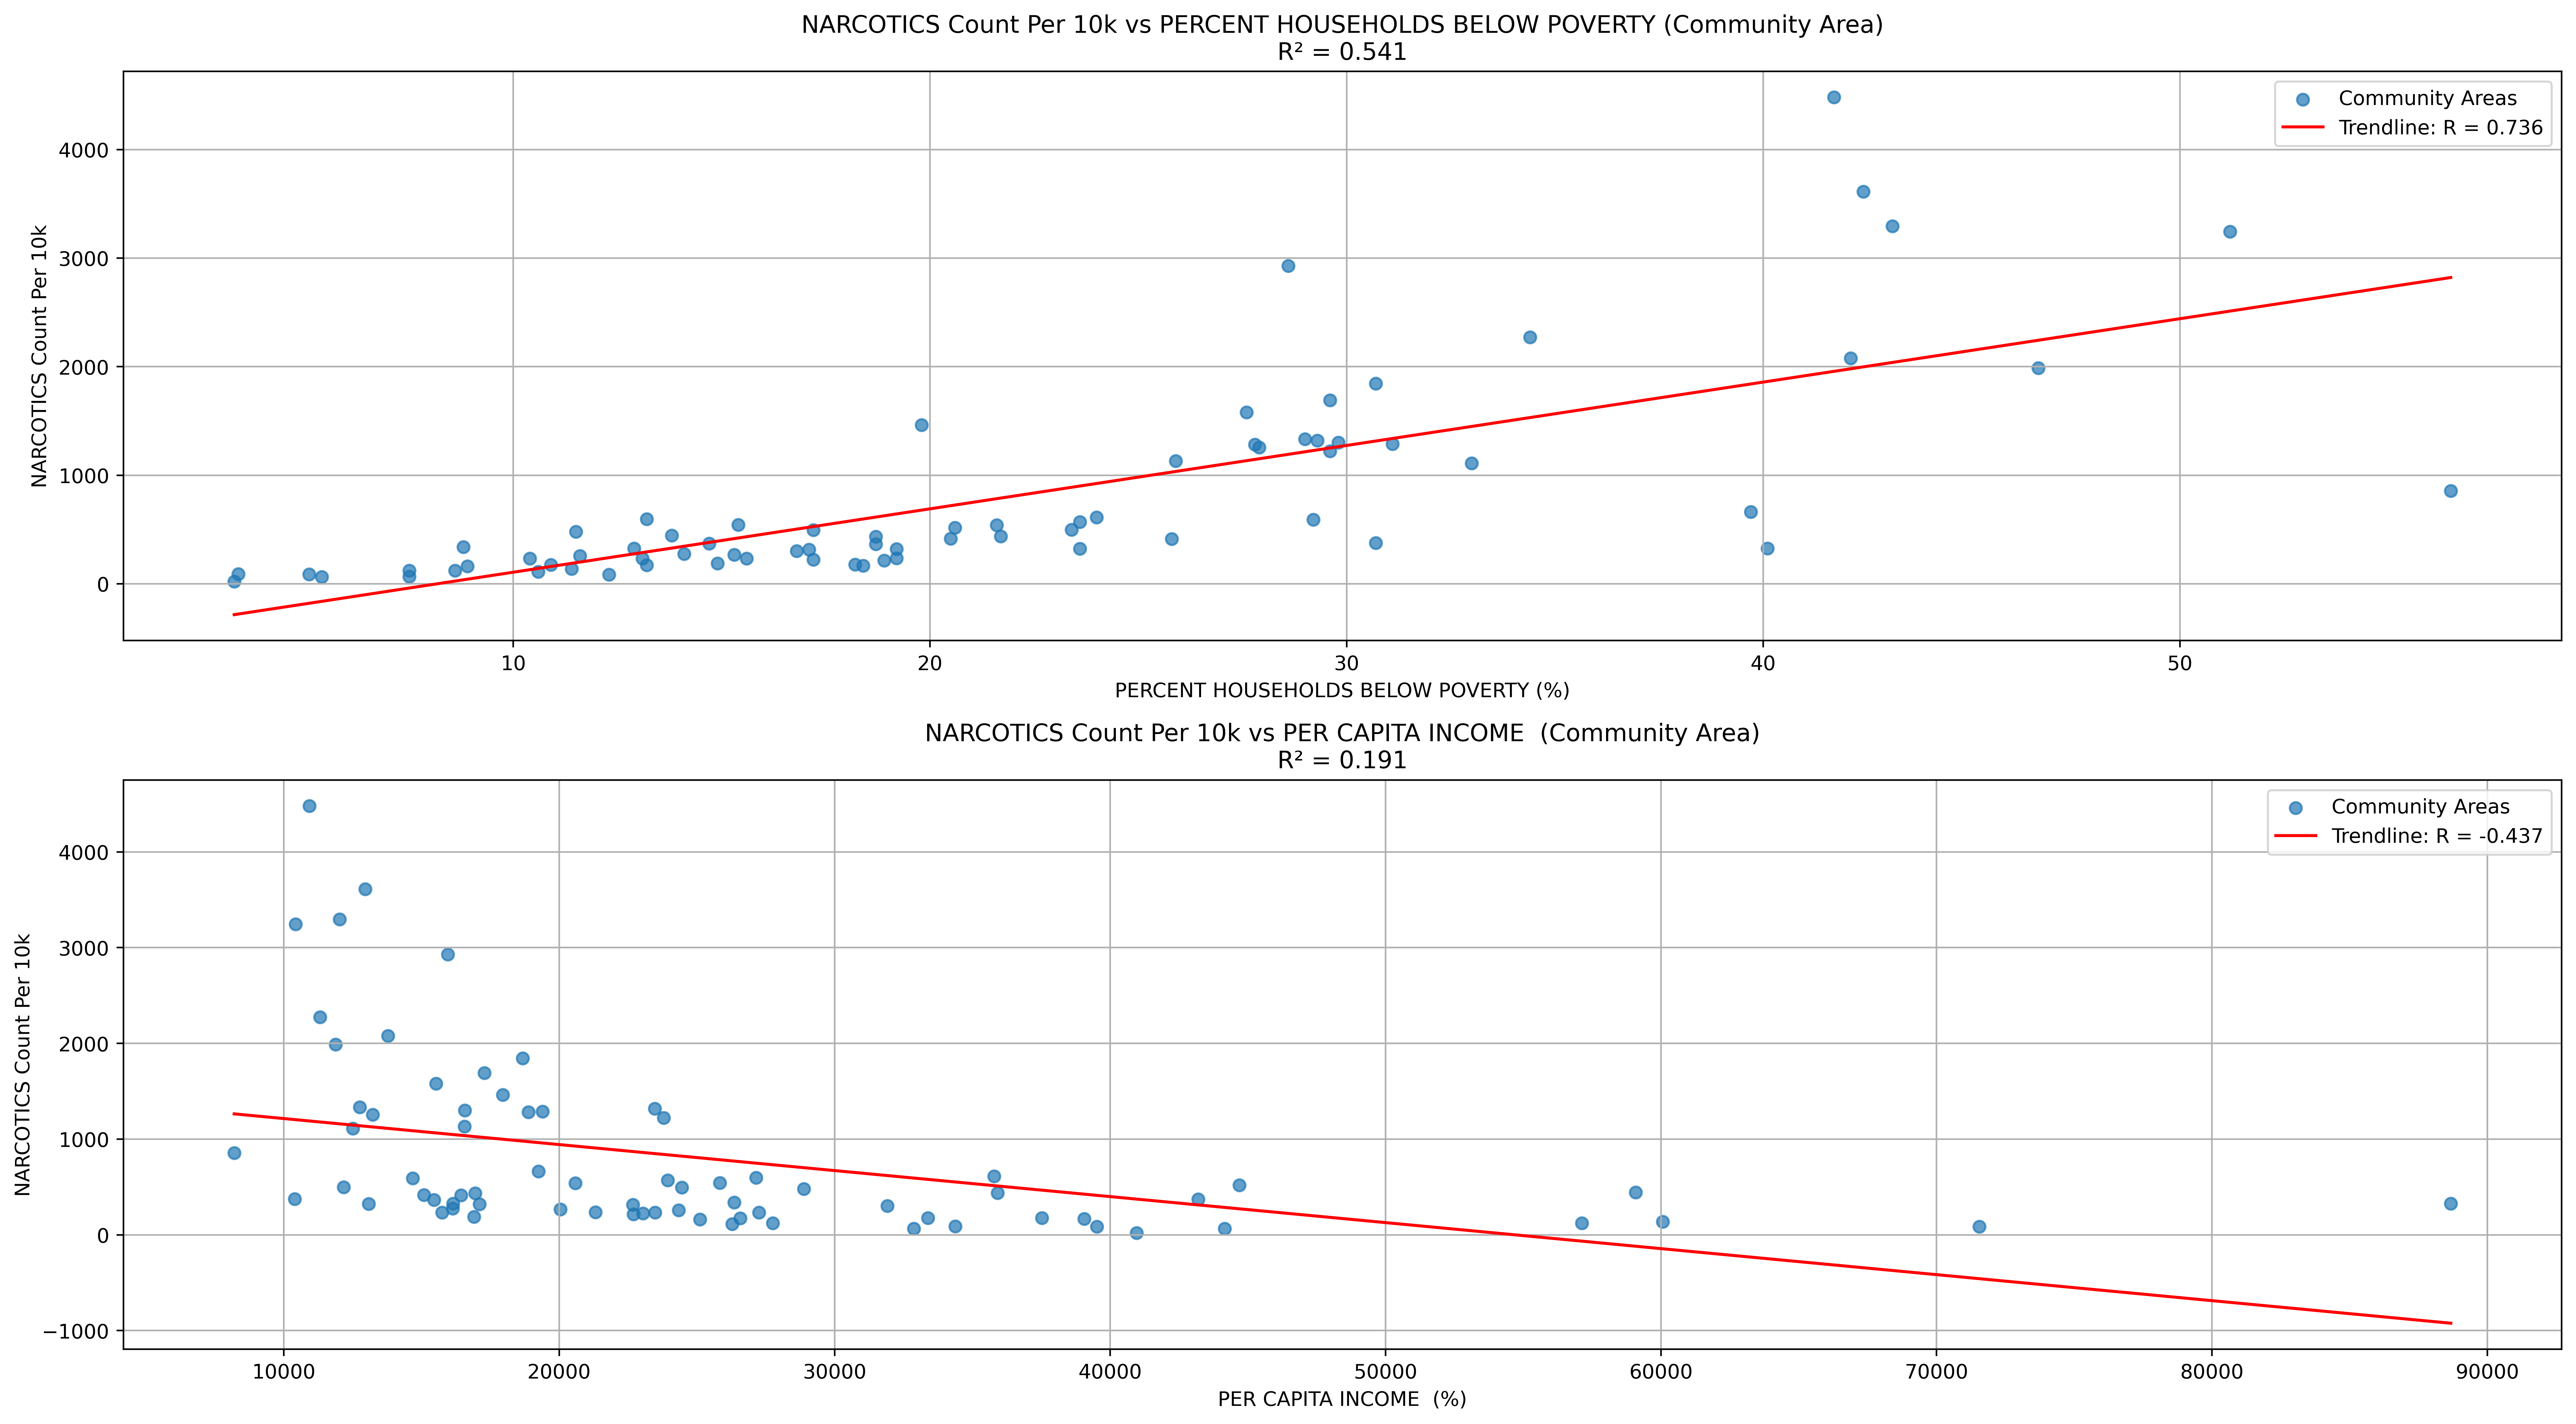

In [22]:
narcotics_categories = ["NARCOTICS"]
narcotics_data = cd[cd['Primary Type'].isin(narcotics_categories)].copy()

crime_by_community = narcotics_data.groupby('Community Area').size().reset_index(name='Crime Count')
crime_by_community = crime_by_community.sort_values(by='Crime Count', ascending=False)


# Merge with sociodata_and_population to get population data
merged_data = pd.merge(
    crime_by_community,
    sociodata_and_population,
    left_on='Community Area',
    right_on='COMMUNITY AREA NAME',
    how='inner'
)

merged_data = merged_data[merged_data['Community Area'] != 'CHICAGO']

# Calculate crimes per 10k residents
merged_data['Crime Count Per 10k'] = (merged_data['Crime Count'] / merged_data['TOT_POP_2010']) * 10000

feature_cols = ["PERCENT HOUSEHOLDS BELOW POVERTY", "PER CAPITA INCOME "]

ncols = 1
nrows = int(np.ceil(len(feature_cols) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows), dpi=500)
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    # Fix comma separated string numbers to floats if needed
    if merged_data[col].dtype == 'object':
        merged_data[col] = merged_data[col].str.replace(',', '.').astype(float)

    x = merged_data[col].values.reshape(-1, 1)
    y = merged_data['Crime Count Per 10k'].values

    model = LinearRegression().fit(x, y)
    y_pred = model.predict(x)
    r2 = model.score(x, y)

    axes[i].scatter(merged_data[col], merged_data['Crime Count Per 10k'], alpha=0.7)
    x_sorted = np.sort(merged_data[col].values)
    axes[i].plot(x_sorted, model.predict(x_sorted.reshape(-1, 1)), color='red')
    axes[i].set_xlabel(f'{col} (%)')
    axes[i].set_ylabel('NARCOTICS Count Per 10k')
    axes[i].set_title(f'NARCOTICS Count Per 10k vs {col} (Community Area)\nR² = {r2:.3f}')
    axes[i].legend(['Community Areas', 'Trendline: R = {:.3f}'.format(np.sqrt(r2))])
    if i == 1:
        axes[i].legend(['Community Areas', 'Trendline: R = -{:.3f}'.format(np.sqrt(r2))])
    axes[i].grid()

for j in range(len(feature_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('../docs/figures/narcotics_vs_socioeconomic.png')
plt.show()


## Discussion
<!-- Think critically about your creation -->
<!-- What went well? -->
<!-- What is still missing? What could be improved? Why? -->

### What went well?

We think that the website and the visualizations turned out very well and played a big role in presenting our data analysis. The final website communicates the results in a visually appealing way that makes it easy for readers to understand the key findings without needing prior knowledge of the topic.

Another aspect we believe worked well is how intuitive and easy to navigate the website is. The layout is clean, and the sections are organized logically, which helps guide the reader through the project. The visualizations are clear, focused, and informative, and we aimed to highlight the most important insights effectively.

We also think it worked well to combine and integrate multiple datasets in our analysis. By bringing together crime data and socioeconomic data, we were able to explore the relationship between crime and socioeconomic standing across different areas of Chicago. This allowed us to conduct a more meaningful analysis of how social factors may be connected to crime levels.

### What is still missing? What could be improved? Why?

Although we are happy with the final results, there are a couple of things that could improve the project. One major limitation we faced was the time span of the socioeconomic dataset. Because the data only covers the years 2008 to 2012, our analysis of crime and socioeconomic indicators was restricted to this period. It would therefore have been beneficial to include more recent data that better reflects the current situation in Chicago. A larger time range could also have made it possible to examine whether the relationships we observed change over time or are influenced by specific events or seasonal patterns.

In a future iteration, it could also be interesting to include additional variables that may help explain differences between neighborhoods. For example, data on ethnicity across the different areas could provide further context and potentially reveal underlying demographic patterns or biases. Other potentially relevant variables could include factors such as housing conditions, education levels, or access to public services.

Finally, with more time, another area of improvement would be to create a clearer progression between the pages. A more explicit narrative flow could make the structure easier to follow and help readers better understand how each section contributes to the overall argument.

## Contributions

| Task | s214643 | s224225 | s224197 |
| --- | --- | --- | --- |
| Helper Notebook | 40% | 30% | 30% |
| Visualizations | 30% | 40% | 30% |
| Design and Aesthetics | 40% | 40% | 20% |
| Overview page | 35% | 35% | 30% |
| Hardship page and analysis | 25% | 25% | 50% |
| Crime page and analysis | 50% | 25% | 25% |
| Correlation page and analysis | 25% | 50% | 25% |
| Discussion and Conclusion page | 35% | 30% | 35% |
